In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
df=pd.read_csv("Housing.csv")

In [3]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
gues

In [5]:
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


Before removing duplicates: (545, 13)
After removing duplicates: (545, 13)


In [7]:
numeric_df = df.select_dtypes(include=[np.number])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]
print("After removing outliers:", df.shape)


After removing outliers: (463, 13)


In [8]:
df = pd.get_dummies(df, drop_first=True)
df.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,9100000,6000,4,1,2,2,True,False,True,False,False,False,True,False
16,9100000,6600,4,2,2,1,True,True,True,False,True,True,False,True
18,8890000,4600,3,2,2,2,True,True,False,False,True,False,False,False
19,8855000,6420,3,2,2,1,True,False,False,False,True,True,True,False
20,8750000,4320,3,1,2,2,True,False,True,True,False,False,True,False


In [9]:
X = df.drop('price', axis=1)
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (370, 13)
Testing shape: (93, 13)


In [10]:
# Step 9: Train and Evaluate Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(kernel='rbf')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df


,Model,R2 Score,MSE,RMSE,MAE
0,Linear Regression,0.611101,1.012526e+12,1.006244e+06,7.576762e+05
1,Random Forest,0.593366,1.058700e+12,1.028931e+06,7.587695e+05
2,KNN,0.547693,1.177611e+12,1.085178e+06,8.152734e+05
3,Decision Tree,0.366538,1.649261e+12,1.284235e+06,9.661882e+05
4,SVM,-0.044907,2.720487e+12,1.649390e+06,1.306995e+06


C:\Users\thanm\AppData\Local\Temp\ipykernel_16432\594283663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")


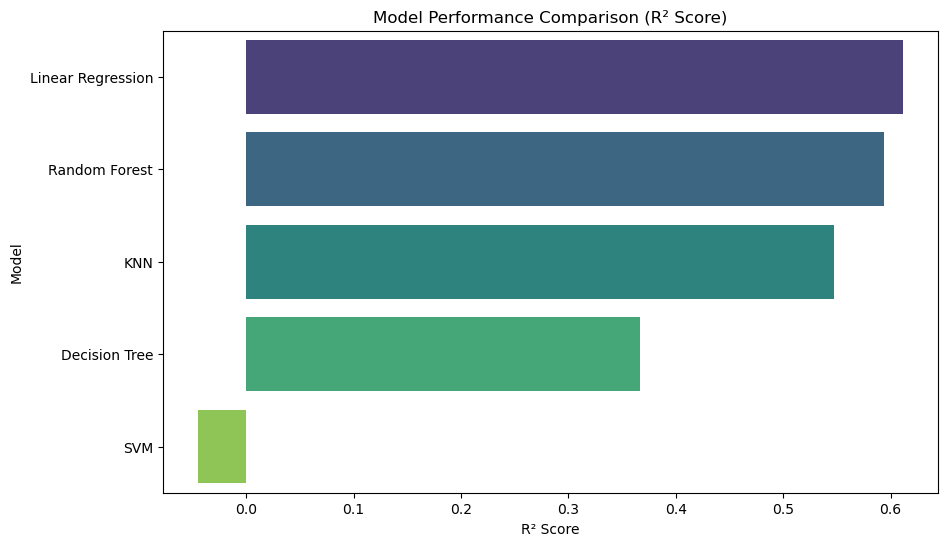

In [11]:
# Step 10: Visualize Model Performance
plt.figure(figsize=(10,6))
sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")
plt.title("Model Performance Comparison (R² Score)")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()


In [12]:
# Step 11: Print Best Model Summary
best_model = results_df.iloc[0]
print(" Best Performing Model:", best_model['Model'])
print(f"R² Score: {best_model['R2 Score']:.3f}")
print(f"RMSE: {best_model['RMSE']:.2f}")
print(f"MAE: {best_model['MAE']:.2f}")


 Best Performing Model: Linear Regression
R² Score: 0.611
RMSE: 1006243.63
MAE: 757676.20
